In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# 1. Data Collection

In [51]:
from datetime import datetime

now = datetime.now()

start=datetime(now.year-10,now.month,now.day)
end=now
ticker = 'AAPL'
df = yf.download(ticker,start,end)
df

$AAPL: possibly delisted; no price data found  (1d 2016-05-04 00:00:00 -> 2026-05-04 22:11:11.613053)
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: possibly delisted; no price data found  (1d 2016-05-04 00:00:00 -> 2026-05-04 22:11:11.613053)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,


In [5]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-05-04,21.332195,21.719477,21.248397,21.560939,164102000
2016-05-05,21.245607,21.434731,21.118007,21.418781,143562000
2016-05-06,21.127123,21.293459,20.928885,21.275232,174799600
2016-05-09,21.143068,21.366369,21.097495,21.190919,131745600
2016-05-10,21.286625,21.320804,20.988130,21.266118,134747200


In [6]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-04-27,267.609985,268.359985,265.070007,266.089996,41466800
2026-04-28,270.709991,273.230011,268.660004,272.339996,40018900
2026-04-29,270.170013,271.040009,267.040009,267.549988,30047900
2026-04-30,271.350006,276.000000,268.140015,270.500000,91848200
2026-05-01,280.140015,287.220001,278.369995,278.859985,79844600


# 2. Data Exploration and Vizualization

In [7]:
type(df)
df.shape
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [8]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,122.102643,123.320868,120.772011,121.995757,9.731724e+07
std,75.834377,76.570910,75.040419,75.778079,5.507953e+07
min,20.584812,20.887868,20.386576,20.507344,1.791060e+07
25%,44.475689,44.845954,44.155694,44.454477,5.841450e+07
50%,128.041473,129.335954,126.492997,128.204089,8.570000e+07
75%,178.039688,179.431967,175.730500,177.984098,1.183390e+08
max,285.922455,288.350192,283.035157,285.932471,4.479400e+08


In [9]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [10]:
# Reset Index to Integer rather than date
df = df.reset_index()

In [11]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-05-04,21.332195,21.719477,21.248397,21.560939,164102000
1,2016-05-05,21.245607,21.434731,21.118007,21.418781,143562000
2,2016-05-06,21.127123,21.293459,20.928885,21.275232,174799600
3,2016-05-09,21.143068,21.366369,21.097495,21.190919,131745600
4,2016-05-10,21.286625,21.320804,20.988130,21.266118,134747200


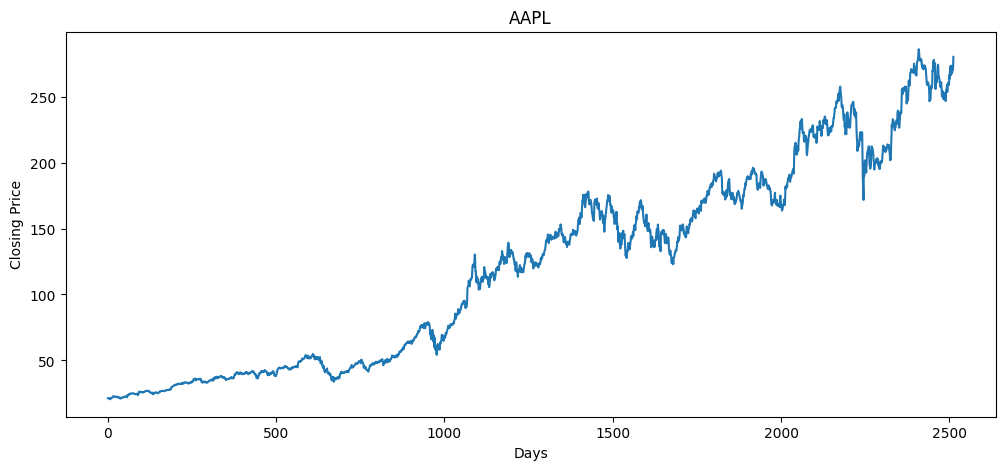

In [12]:
plt.figure(figsize = (12,5))
plt.plot(df.Close);
plt.title(ticker);
plt.xlabel('Days');
plt.ylabel ('Closing Price');

# 3. Feature Engineering

In [13]:
df1=pd.DataFrame(df.Close);
df1

Ticker,AAPL
0,21.332195
1,21.245607
2,21.127123
3,21.143068
4,21.286625
...,...
2508,267.609985
2509,270.709991
2510,270.170013
2511,271.350006


In [14]:
# Calculating the moving average for 50 days
df1['MA_100'] = df.Close.rolling(100).mean()
df1.head(200)

Ticker,AAPL,MA_100
0,21.332195,NaN
1,21.245607,NaN
2,21.127123,NaN
3,21.143068,NaN
4,21.286625,NaN
...,...,...
195,30.555178,26.670529
196,30.825752,26.718605
197,31.225851,26.770728
198,31.339167,26.821532


Text(0, 0.5, 'Price')

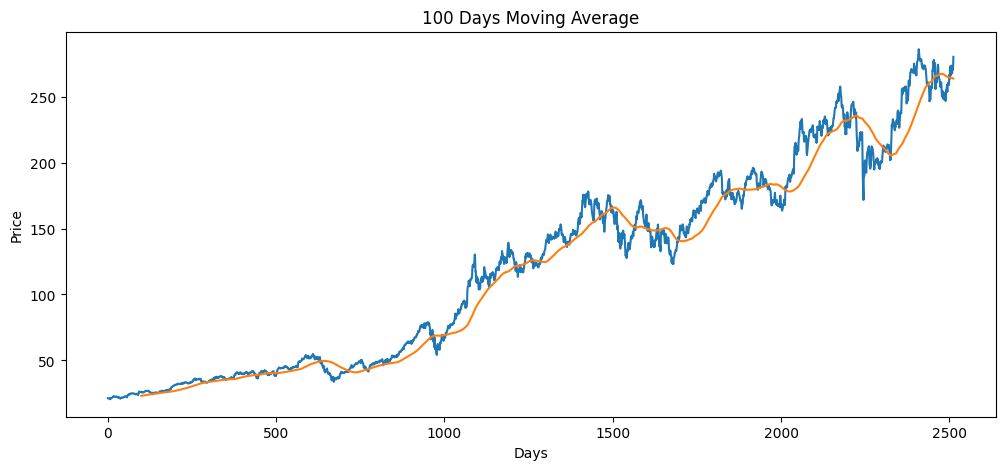

In [15]:
plt.figure(figsize =(12,5))
plt.plot(df.Close);
plt.plot(df1['MA_100']);
plt.title('100 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

# 200 Days Moving Average

In [16]:
#df1
df1['MA_200'] = df.Close.rolling(200).mean()
df1

Ticker,AAPL,MA_100,MA_200
0,21.332195,NaN,NaN
1,21.245607,NaN,NaN
2,21.127123,NaN,NaN
3,21.143068,NaN,NaN
4,21.286625,NaN,NaN
...,...,...,...
2508,267.609985,264.058039,253.622040
2509,270.709991,263.905914,253.922994
2510,270.170013,263.768770,254.233908
2511,271.350006,263.677895,254.548280


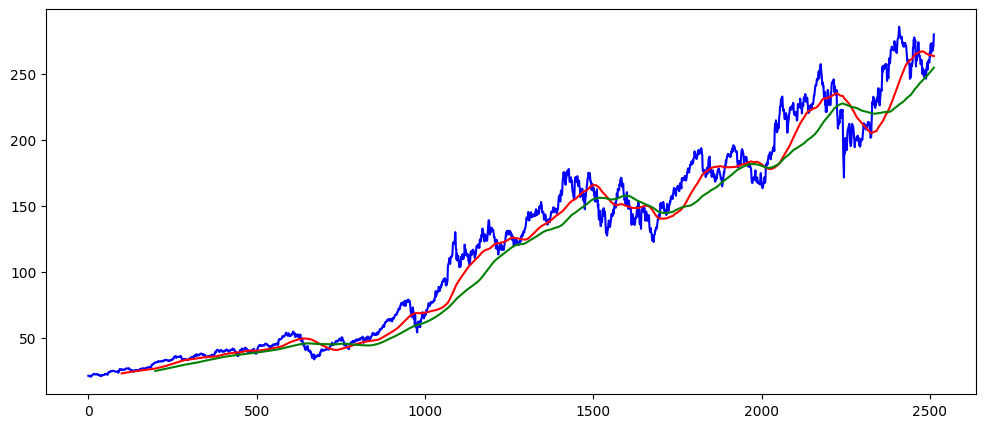

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df.Close,color='blue');
plt.plot(df1['MA_100'],color='red');
plt.plot(df1['MA_200'],color='green');

In [18]:
# Percentage change in stock price everyday
df1['percentage_change'] = df.Close.pct_change()
df1

Ticker,AAPL,MA_100,MA_200,percentage_change
0,21.332195,NaN,NaN,NaN
1,21.245607,NaN,NaN,-0.004059
2,21.127123,NaN,NaN,-0.005577
3,21.143068,NaN,NaN,0.000755
4,21.286625,NaN,NaN,0.006790
...,...,...,...,...
2508,267.609985,264.058039,253.622040,-0.012728
2509,270.709991,263.905914,253.922994,0.011584
2510,270.170013,263.768770,254.233908,-0.001995
2511,271.350006,263.677895,254.548280,0.004368


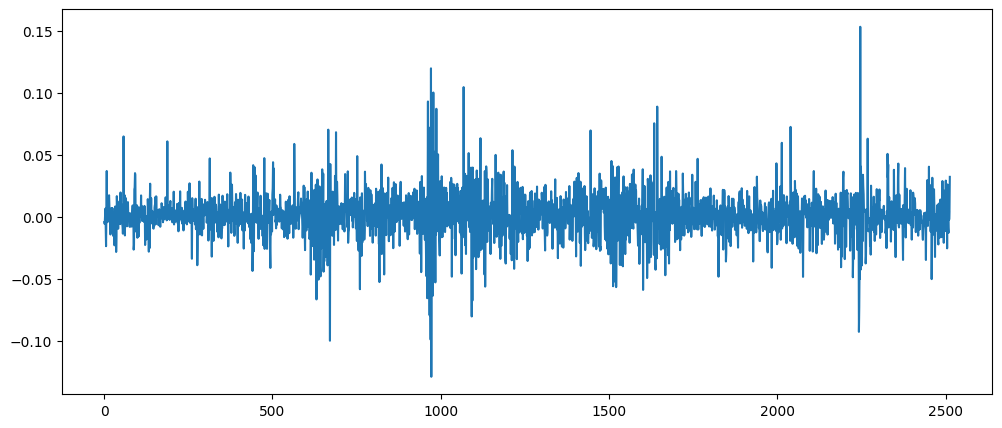

In [19]:
plt.figure(figsize=(12,5))
plt.plot(df1.percentage_change)

# 4. Data Preprocessing

In [24]:
# Splitting Data into Training and Testing Datasets

data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
print(data_training)
type(data_training)

Ticker        AAPL
0        21.332195
1        21.245607
2        21.127123
3        21.143068
4        21.286625
...            ...
1754    162.969040
1755    161.431320
1756    161.421463
1757    166.005035
1758    167.256943

[1759 rows x 1 columns]


pandas.DataFrame

In [21]:
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7):len(df)])
print(data_testing)

Ticker        AAPL
1759    167.168213
1760    166.133209
1761    165.058777
1762    163.422485
1763    171.091385
...            ...
2508    267.609985
2509    270.709991
2510    270.170013
2511    271.350006
2512    280.140015

[754 rows x 1 columns]


In [27]:
# Scaling down Data into a range of 0 and 1
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1));
training_data_array = scaler.fit_transform(data_training)
print(training_data_array)

training_data_array.shape
type(training_data_array)

[[0.00474472]
 [0.00419502]
 [0.00344283]
 ...
 [0.89409383]
 [0.92319239]
 [0.93114006]]


numpy.ndarray

In [ ]:
# Creating Data Sequence
# Tomorrow's stock price is dependent on previous days stock price
# 1,2,3,4,5,6 --> X_train && 7 --> Y_train

X_train = []
Y_train = []

for i in range(100,training_data_array.shape[0]):
    X_train.append(training_data_array[i-100:i])
    Y_train.append(training_data_array[i, 0])
    



In [40]:
x_train = np.array(X_train)
x_train

array([[[0.00474472],
        [0.00419502],
        [0.00344283],
        ...,
        [0.03446432],
        [0.03602053],
        [0.03324264]],

       [[0.00419502],
        [0.00344283],
        [0.00354406],
        ...,
        [0.03602053],
        [0.03324264],
        [0.03348989]],

       [[0.00344283],
        [0.00354406],
        [0.00445542],
        ...,
        [0.03324264],
        [0.03348989],
        [0.03379531]],

       ...,

       [[0.79424666],
        [0.79599603],
        [0.79287227],
        ...,
        [0.90197853],
        [0.90391854],
        [0.89415641]],

       [[0.79599603],
        [0.79287227],
        [0.78549904],
        ...,
        [0.90391854],
        [0.89415641],
        [0.89409383]],

       [[0.79287227],
        [0.78549904],
        [0.76225577],
        ...,
        [0.89415641],
        [0.89409383],
        [0.92319239]]], shape=(1659, 100, 1))

In [38]:
Y_train

array([0.03348989, 0.03379531, 0.0350461 , ..., 0.89409383, 0.92319239,
       0.93114006], shape=(1659,))

In [39]:
y_train=np.array(Y_train)
y_train

array([0.03348989, 0.03379531, 0.0350461 , ..., 0.89409383, 0.92319239,
       0.93114006], shape=(1659,))

In [ ]:
X_train, Y_train = np.array(X_train), np.array(Y_train)

In [45]:
x_train.ndim
type(x_train)
x_train.shape

(1659, 100, 1)

In [42]:
y_train.shape

(1659,)

# 6. Model Buildiing

In [63]:
from datetime import datetime

now = datetime.now()

start=datetime(now.year-10,now.month,now.day)
end=now
ticker = 'AAPL'
df = yf.download(ticker,start,end)
df

$AAPL: possibly delisted; no price data found  (1d 2016-05-05 00:00:00 -> 2026-05-05 00:42:26.971817)
[*********************100%***********************]  1 of 1 completed



1 Failed download:
['AAPL']: possibly delisted; no price data found  (1d 2016-05-05 00:00:00 -> 2026-05-05 00:42:26.971817)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
